<a href="https://colab.research.google.com/github/siri-chandana-macha/Data_Science_Tasks/blob/main/TaxiTripPrice_DecisionTreeClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# load the dataset
df=pd.read_csv("/content/taxi_trip_pricing (1).csv")
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [4]:
# check for null values
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [5]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

In [22]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_absolute_error

In [23]:
# encoding
encoder=LabelEncoder()
for col in df.columns:
  if df[col].dtype == 'object':
    df[col]=encoder.fit_transform(df[col])
df

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,2,0,3.0,1,0,3.560000,0.800000,0.320000,53.82,36.262400
1,47.590000,0,0,1.0,0,0,3.502989,0.620000,0.430000,40.57,56.874773
2,36.870000,1,1,1.0,0,0,2.700000,1.210000,0.150000,37.27,52.903200
3,30.330000,1,0,4.0,1,0,3.480000,0.510000,0.150000,116.81,36.469800
4,27.070547,1,0,3.0,0,0,2.930000,0.630000,0.320000,22.64,15.618000
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,0,1,4.0,2,0,2.390000,0.620000,0.490000,58.39,34.404900
996,45.950000,3,0,4.0,2,0,3.120000,0.610000,0.292916,61.96,62.129500
997,7.700000,2,0,3.0,1,1,2.080000,1.780000,0.292916,54.18,33.123600
998,47.560000,2,0,1.0,1,0,2.670000,0.820000,0.170000,114.94,61.209000


In [7]:
X=df.drop("Trip_Price",axis=1)
y=df["Trip_Price"]

Xtrain,Xtest,ytrain,ytest=train_test_split(X,y,test_size=0.3,random_state=42)

In [14]:
from sklearn.tree import DecisionTreeRegressor
model=DecisionTreeRegressor(max_depth=5)
model.fit(Xtrain,ytrain)

DecisionTreeRegressor(max_depth=5)

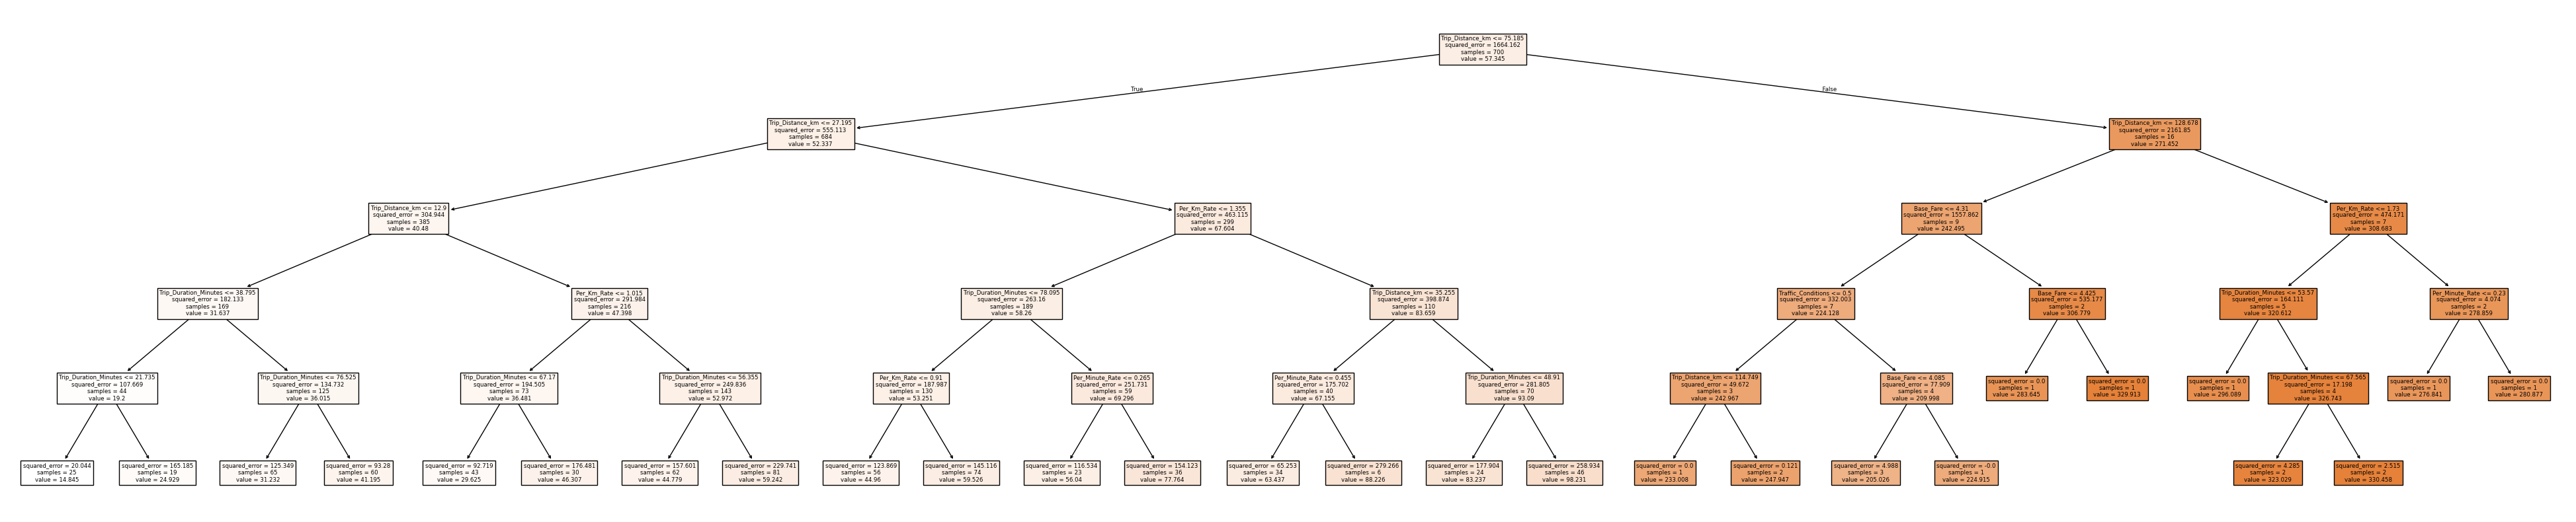

In [19]:
# Tree Visualization
from sklearn.tree import plot_tree
plt.figure(figsize=(50,10)) # Increased figure size for better readability
plot_tree(model,feature_names=X.columns.tolist(),filled=True) # Use X.columns for feature names
plt.show()

In [20]:
ypred=model.predict(Xtest)
ypred

array([ 59.24232576,  83.23718944,  44.77917011,  59.24232576,
        98.2311271 ,  44.95982226,  29.62513426,  44.95982226,
        41.19532911,  59.24232576,  59.52555261,  98.2311271 ,
        59.24232576,  31.23232564,  14.845072  ,  14.845072  ,
        59.52555261,  31.23232564,  29.62513426,  44.77917011,
        59.52555261,  44.95982226,  14.845072  ,  44.77917011,
        56.03985971,  77.76446796,  63.43676157,  59.52555261,
        31.23232564,  77.76446796,  77.76446796,  59.52555261,
        31.23232564,  98.2311271 ,  41.19532911,  98.2311271 ,
        44.77917011,  44.77917011,  31.23232564,  59.24232576,
        44.77917011,  29.62513426,  41.19532911,  41.19532911,
        31.23232564,  59.52555261,  59.24232576,  46.30687911,
        29.62513426,  46.30687911,  59.24232576,  31.23232564,
        56.03985971,  59.24232576,  29.62513426,  56.03985971,
        46.30687911,  29.62513426,  77.76446796,  44.95982226,
        83.23718944,  63.43676157,  41.19532911,  41.19

In [24]:
print("r2 score: ",r2_score(ytest,ypred))
print("MAE: ",mean_absolute_error)

r2 score:  0.8305681510673774
MAE:  <function mean_absolute_error at 0x7bc740da7880>
